In [ ]:
%pip install yfinance
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Data Acquisition
We use the `yfinance` library to fetch historical price data for the S&P 500 ETF (SPY). 
`auto_adjust = True` makes `yfinance` automatically adjusts historical stock prices for splits and dividends.

[*********************100%***********************]  1 of 1 completed

Columns available: MultiIndex([( 'Close', 'SPY'),
            (  'High', 'SPY'),
            (   'Low', 'SPY'),
            (  'Open', 'SPY'),
            ('Volume', 'SPY')],
           names=['Price', 'Ticker'])


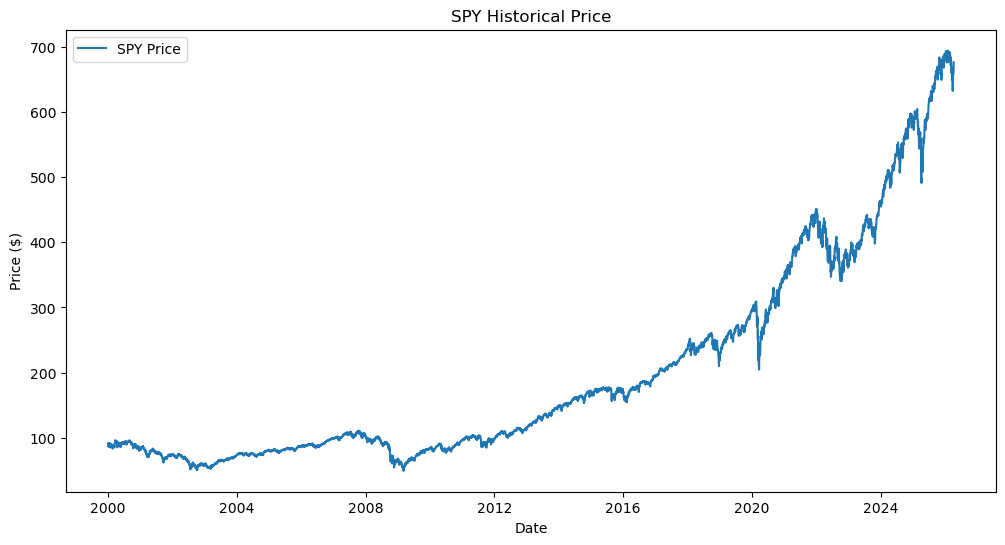

In [107]:
# Pull Historical Data
ticker = "SPY"

data = yf.download(ticker, start="2000-01-01", end="2026-04-09",auto_adjust=True)

# Look at the data columns to verify
print("Columns available:", data.columns)

# Plot
plt.figure(figsize=(12,6))

plt.plot(data['Close'], label=f'{ticker} Price')
plt.title(f"{ticker} Historical Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

## 2. Technical Indicator Generation
A Simple Moving Average (SMA) is calculated by taking the arithmetic mean of a given set of prices over a specific number of days.
* **SMA 50 (Fast):** Captures short-term momentum.
* **SMA 200 (Slow):** Identifies the long-term trend.
We use a "sliding window" approach via the `.rolling()` method to generate these values.
* Example: for SMA50 day 1 to day 50 average value is ploted on day 51.

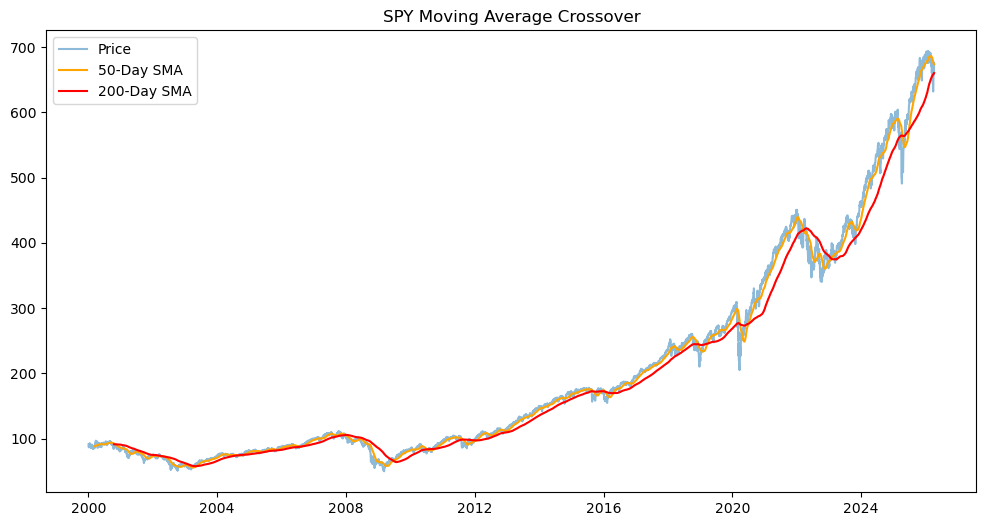

In [108]:
data["SMA50"] = data["Close"].rolling(window=50).mean()
data['SMA200'] = data['Close'].rolling(window=200).mean()

# Plot the price with the averages
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Price', alpha=0.5)
plt.plot(data['SMA50'], label='50-Day SMA', color='orange')
plt.plot(data['SMA200'], label='200-Day SMA', color='red')
plt.title(f"{ticker} Moving Average Crossover")
plt.legend()
plt.show()

## 3. Signal Generation Logic
We define a **Golden Cross** (Buy) as the point where the 50-day SMA crosses above the 200-day SMA. Conversely, a **Death Cross** (Sell) occurs when the 50-day SMA drops below the 200-day SMA.
* **Signal:** 1 for "Long" (invested), 0 for "Cash".
* **Position:** The daily change in signal. A value of `1` indicates a trade entry, and `-1` indicates an exit.

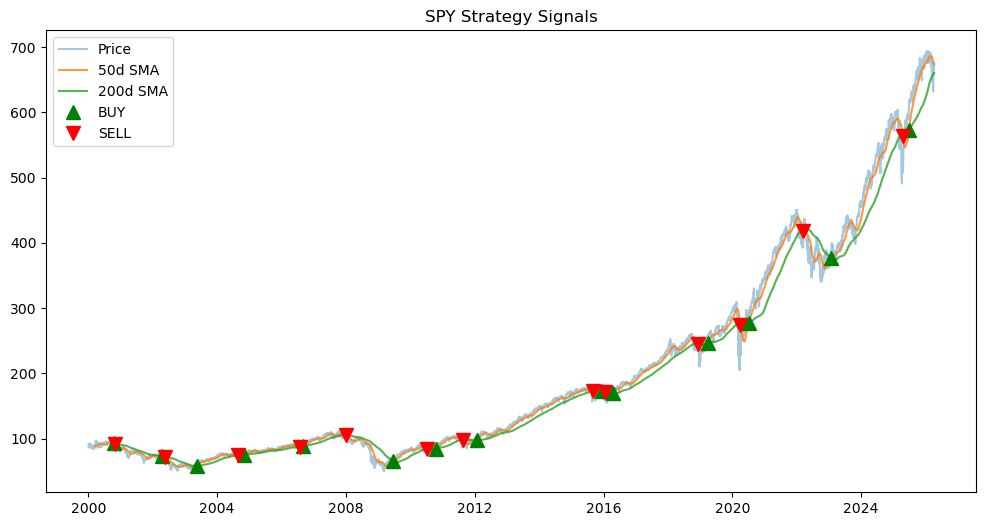

In [ ]:
# Generate the signal: 1 if 50 SMA is above 200 SMA, 0 otherwise
data['Signal'] = 0
# We use np.where for a vectorized 'if' statement
import numpy as np
data['Signal'] = np.where(data['SMA50'] > data['SMA200'], 1, 0)

# Identify the 'Crossovers'
# The 'Position' is the difference in signals. 
# 1 means we just bought, -1 means we just sold.
data['Position'] = data['Signal'].diff()

# Plot the price with Buy/Sell markers
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Price', alpha=0.4)
plt.plot(data['SMA50'], label='50d SMA', alpha=0.8)
plt.plot(data['SMA200'], label='200d SMA', alpha=0.8)

# Plot Buy
plt.plot(data[data['Position'] == 1].index, 
         data['SMA50'][data['Position'] == 1], 
         '^', markersize=10, color='g', label='BUY')

# Plot Sell
plt.plot(data[data['Position'] == -1].index, 
         data['SMA50'][data['Position'] == -1], 
         'v', markersize=10, color='r', label='SELL')

plt.title(f"{ticker} Strategy Signals")
plt.legend()
plt.show()

## 4. Backtesting Strategy Performance
To evaluate the strategy, we compare the **Strategy Returns** against a **Buy & Hold** benchmark.
* **Market Returns:** The daily percentage change of the asset.
* **Strategy Returns:** The market return multiplied by our position from the *previous* day (to avoid look-ahead bias).
* **Cumulative Returns:** The geometric progression of daily returns over the 26-year period.


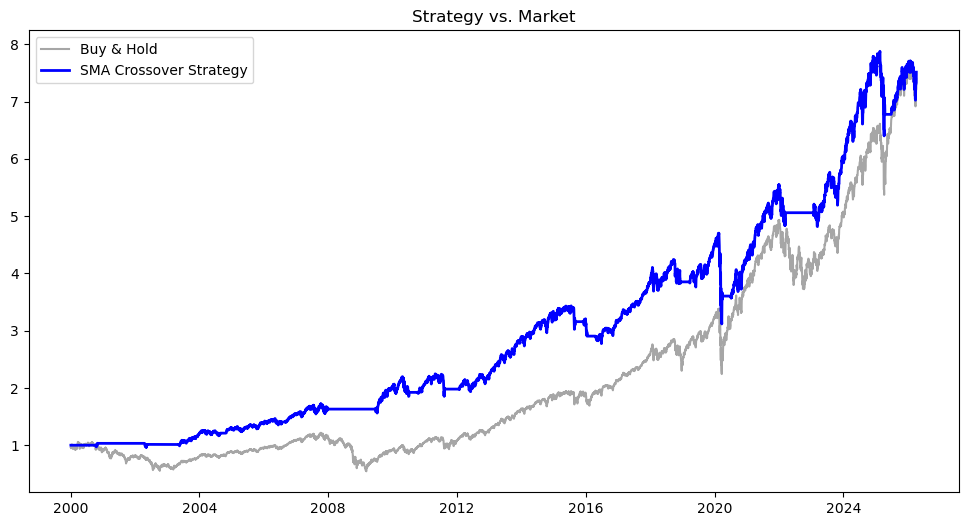

Total Market Return:   7.40x
Total Strategy Return: 7.51x


In [110]:
# Calculate Daily Market Returns
data['Market_Returns'] = data['Close'].pct_change()

# Calculate Strategy Returns
# .shift(1) since we can only trade from yesterdays calls
data['Strategy_Returns'] = data['Market_Returns'] * data['Signal'].shift(1)

# Compare Cumulative Returns
data['Cumulative_Market'] = (1 + data['Market_Returns']).cumprod()
data['Cumulative_Strategy'] = (1 + data['Strategy_Returns']).cumprod()

# Plot the comparison
plt.figure(figsize=(12,6))
plt.plot(data['Cumulative_Market'], label='Buy & Hold', color='gray', alpha=0.7)
plt.plot(data['Cumulative_Strategy'], label='SMA Crossover Strategy', color='blue', linewidth=2)
plt.title("Strategy vs. Market")
plt.legend()
plt.show()

# Total return
print(f"Total Market Return:   {data['Cumulative_Market'].iloc[-1]:.2f}x")
print(f"Total Strategy Return: {data['Cumulative_Strategy'].iloc[-1]:.2f}x")

## 5. Risk Management: Maximum Drawdown
In Quantitative Finance, absolute return is only half the story. We must measure the "Pain" involved. 
**Maximum Drawdown** represents the largest peak-to-trough decline in the portfolio's value. This metric is crucial for understanding the safety of the strategy during market crashes like 2000 and 2008.


We use the following metrics to compare the Strategy vs. Benchmark:
* **CAGR:** Compounded Annual Growth Rate.
* **Max Drawdown:** The worst-case loss scenario.
* **Sharpe Ratio:** The risk-adjusted return (Reward per unit of risk).

In [111]:
def calculate_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown

data['Market_Drawdown'] = calculate_drawdown(data['Cumulative_Market'])
data['Strategy_Drawdown'] = calculate_drawdown(data['Cumulative_Strategy'])

def get_summary_stats(cum_returns, daily_returns, drawdowns):
    total_return = (cum_returns.iloc[-1] - 1) * 100
    max_drawdown = drawdowns.min() * 100
    years = len(cum_returns) / 252
    cagr = (cum_returns.iloc[-1]**(1/years) - 1) * 100
    
    # Calculate Annualized Sharpe Ratio
    # Formula: (Mean Return / Std Dev) * sqrt(252 days)
    sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
    
    return {
        "Total Return (%)": f"{total_return:.2f}%",
        "Max Drawdown (%)": f"{max_drawdown:.2f}%",
        "Annualized (CAGR)": f"{cagr:.2f}%",
        "Sharpe Ratio": f"{sharpe:.2f}"
    }

market_stats = get_summary_stats(data['Cumulative_Market'], data['Market_Returns'], data['Market_Drawdown'])
strategy_stats = get_summary_stats(data['Cumulative_Strategy'], data['Strategy_Returns'], data['Strategy_Drawdown'])

summary_df = pd.DataFrame([market_stats, strategy_stats], index=['Buy & Hold', 'SMA Strategy'])
print(summary_df)

             Total Return (%) Max Drawdown (%) Annualized (CAGR) Sharpe Ratio
Buy & Hold            639.88%          -55.19%             7.93%         0.49
SMA Strategy          651.34%          -33.72%             8.00%         0.67
